<a href="https://colab.research.google.com/github/MrCherveN/Bank-Marketing-Campaign-Deposit-Prediction/blob/main/Mid_term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

##Import all neccessery libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import confusion_matrix, f1_score, auc, roc_curve, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import shap


import importlib
import bank_marketing_campaigns
importlib.reload(bank_marketing_campaigns)
from bank_marketing_campaigns import preprocess_data, split_and_engineer, evaluate_model, plot_one_model_cf, predict_and_plot_cf, predict_and_plot_roc_auc_all, update_metrics_dict

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.4f}'.format)

warnings.filterwarnings('ignore')

##1.Exploratory Data Analysis (EDA) and Hypothesis Formulation on Feature Influence on the Target Variable

In [ ]:
df = pd.read_csv('/content/bank-additional-full.csv', sep=';')

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no


In [ ]:
null_count = df.isnull().sum()
null_percentage = round((df.isnull().sum()/df.shape[0])*100, 2)
null_df = pd.DataFrame({'column_name' : df.columns,'null_count' : null_count,'null_percentage': null_percentage})
null_df.reset_index(drop = True, inplace = True)

null_df.sort_values(by = 'null_percentage', ascending = False)

,column_name,null_count,null_percentage
0,age,0,0.0000
1,job,0,0.0000
2,marital,0,0.0000
3,education,0,0.0000
4,default,0,0.0000
5,housing,0,0.0000
6,loan,0,0.0000
7,contact,0,0.0000
8,month,0,0.0000
9,day_of_week,0,0.0000


As we can see, there are no missing values.

In [ ]:
df.shape

(41188, 21)

In [ ]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

To perform correlation analysis and train machine learning models, we convert the categorical target variable y into a numeric format.

In [ ]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [ ]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

####Data Cleaning: Duplicate Removal Detection

In [ ]:
duplicates_count = df.duplicated().sum()
print(f"Number of duplicates in the datasetі: {duplicates_count}")

if duplicates_count > 0:
    duplicated = df[df.duplicated(keep=False)].sort_values(by=list(df.columns[:6]))
    display(duplicated)

Number of duplicates in the datasetі: 12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8000,93.0750,-47.1000,1.4230,5099.1000,0
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8000,93.0750,-47.1000,1.4230,5099.1000,0
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9620,5228.1000,0
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9620,5228.1000,0
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9680,5228.1000,0
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9680,5228.1000,0
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8000,92.8930,-46.2000,1.3130,5099.1000,0
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8000,92.8930,-46.2000,1.3130,5099.1000,0
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9660,5228.1000,0
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9660,5228.1000,0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
df.shape

(41176, 21)

####Analyzing the distribution of the target variable classes

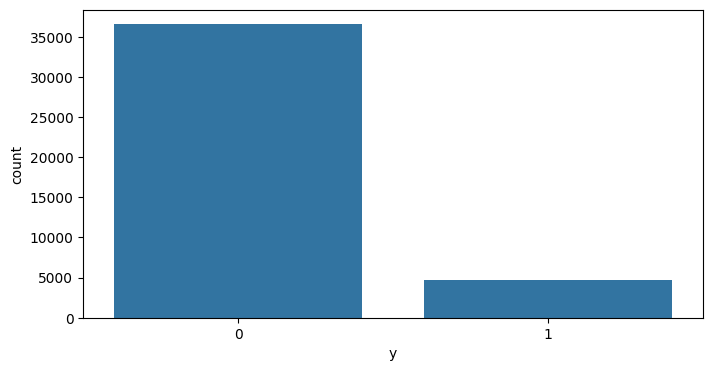

In [ ]:
plt.figure(figsize = (8,4))
sns.countplot(data = df, x = "y")
plt.xticks()
plt.show()

In [ ]:
df['y'].value_counts(normalize=True)

,proportion
y,
0,0.8873
1,0.1127


***Observations:***
- We observe a significant class imbalance in the target variable y. This will need to be taken into account in the future when selecting metrics for evaluating model quality.

####Numerical Variable Analysis

In [ ]:
number_df = df.select_dtypes(include="number").columns
number_df

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Statistical report for numerical variables

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000
mean,40.0238,258.3158,2.5679,962.4648,0.1730,0.0819,93.5757,-40.5029,3.6213,5167.0349,0.1127
std,10.4207,259.3053,2.7703,186.9371,0.4950,1.5709,0.5788,4.6279,1.7344,72.2514,0.3162
min,17.0000,0.0000,1.0000,0.0000,0.0000,-3.4000,92.2010,-50.8000,0.6340,4963.6000,0.0000
25%,32.0000,102.0000,1.0000,999.0000,0.0000,-1.8000,93.0750,-42.7000,1.3440,5099.1000,0.0000
50%,38.0000,180.0000,2.0000,999.0000,0.0000,1.1000,93.7490,-41.8000,4.8570,5191.0000,0.0000
75%,47.0000,319.0000,3.0000,999.0000,0.0000,1.4000,93.9940,-36.4000,4.9610,5228.1000,0.0000
max,98.0000,4918.0000,56.0000,999.0000,7.0000,1.4000,94.7670,-26.9000,5.0450,5228.1000,1.0000


Correlation Heatmap for Numerical Features - Influence on the Target Variable

In [ ]:
df_corr = df.copy()
df_corr['pdays'] = df_corr['pdays'].replace(999, np.nan)
corr_df = df_corr.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool))

top_corr = corr_df[corr_df <= 0.99].unstack().sort_values(ascending=False).head(20)
top_corr

,,0
euribor3m,emp.var.rate,0.9722
emp.var.rate,euribor3m,0.9722
nr.employed,euribor3m,0.9451
euribor3m,nr.employed,0.9451
emp.var.rate,nr.employed,0.9069
nr.employed,emp.var.rate,0.9069
cons.price.idx,emp.var.rate,0.7753
emp.var.rate,cons.price.idx,0.7753
euribor3m,cons.price.idx,0.6882
cons.price.idx,euribor3m,0.6882


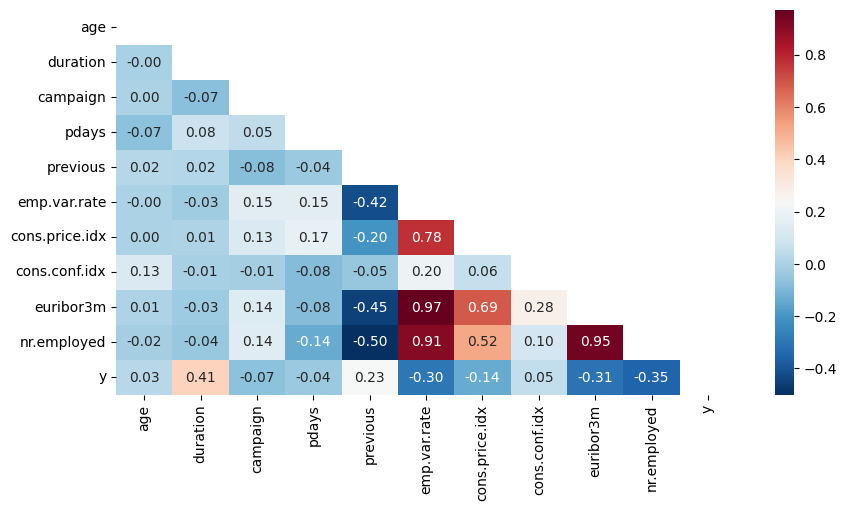

In [ ]:
plt.figure(figsize = (10,5))
sns.heatmap(data = corr_df, mask = mask, annot = True, cmap='RdBu_r', cbar = True, fmt='.2f')
plt.show()

***Observations:***

- The duration feature has the strongest positive relationship with the target variable y (0.41), which is expected according to the task conditions. Since this variable may lead to data leakage, it will be excluded from the final model.

- The age variable has a positive correlation with the dependent variable y (0.03), which may indicate that there is very weak or negligible linear relationship between the variables.

- The campaign variable has a negative correlation with the dependent variable y (-0.07), which may indicate that there is very weak or negligible linear relationshipp between the variables.
- The pdays variable (excluding the value 999) has a negative correlation with the dependent variable y (-0.04). This suggests that the relationship is non-linear.
- The previous feature has the positive relationship with the target variable y (0.23). It shows that the more contact there has been with the customer prior to the current marketing campaign, the higher the likelihood that they will agree to make a deposit now.
- There is an extremely high correlation between the three variables:

          - emp.var.rate and euribor3m (0.97)
          - euribor3m and nr.employed (0.95)
          - emp.var.rate and nr.employed (0.91).
 This should be considered, especially for linear models.

- The features emp.var.rate, euribor3m, and nr.employed show nearly identical negative correlations with the target variable y (-0.30 to -0.35), which may indicate that as these indices increase, customer interest in opening term deposits tends to decrease.

- The cons.price.idx variable has a weak negative correlation with the target variable y (-0.14). This can be interpreted to mean that as the inflation index rises, the customer’s purchasing power declines, leaving them with less disposable income to open a term deposit.

- The cons.conf.idx variable has a positive correlation with the dependent variable y (0.05), which may indicate that there is very weak or negligible linear relationship between the variables.

In [ ]:
def is_contacted(days):
    if days == 999:
        return 0
    else:
        return 1

contacted_df = df.copy()
contacted_df['pdays_mapped'] = contacted_df['pdays'].apply(is_contacted)

conversion = contacted_df.groupby('pdays_mapped')['y'].value_counts(normalize=True)
print(conversion)

pdays_mapped  y
0             0   0.9074
              1   0.0926
1             1   0.6383
              0   0.3617
Name: proportion, dtype: float64


***Observations:***

- The likelihood that a customer will open a deposit account increases nearly sevenfold if they have been contacted before.

####Categorical Variable Analysis

In [ ]:
df_categorical = df.select_dtypes(include = "object")
df_categorical.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

In [ ]:
len(df_categorical.columns)

10

In [ ]:
for col in df_categorical.columns:
    print(f"Column: {col}")
    print(df_categorical[col].value_counts())
    print("\n")

Column: job
job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


Column: marital
marital
married     24921
single      11564
divorced     4611
unknown        80
Name: count, dtype: int64


Column: education
education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64


Column: default
default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64


Column: housing
housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64


Column: loan
loan
no         33938
yes         6248
unknown   

***Observations:***

- Several categorical features (job, marital, education, housing, and loan) contain the “unknown” category, which indicates that information was missing at the time of the call. Since “unknown” occurs frequently, we will leave it as a separate category so that the model can take this into account when making predictions.

In [ ]:
def bi_cat_countplot(df, column, hue_column):
    unique_hue_values = df[hue_column].unique()
    fig, axes = plt.subplots(nrows=1, ncols=2)
    fig.set_size_inches(14,6)

    pltname = f'Normalized distribution of values by category: {column}'
    proportions = df.groupby(hue_column)[column].value_counts(normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[0], title=pltname)

    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.1f}%')

    pltname = f'Observation counts by category: {column}'
    counts = df.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[1], title=pltname)

    for container in ax.containers:
      ax.bar_label(container)


def uni_cat_target_compare(df, column):
    bi_cat_countplot(df, column, hue_column='y')

#####Feature Insight: poutcome




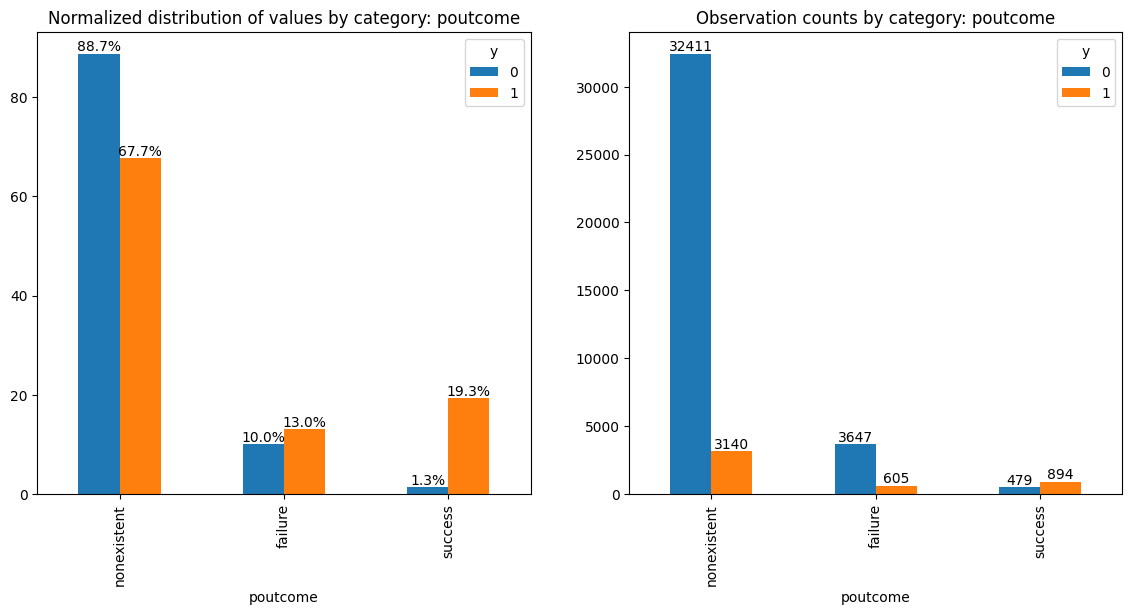

In [ ]:
uni_cat_target_compare(df, 'poutcome')

***Observations:***
- The “nonexistent” group is the most common (over 32,000 entries).
- Among those who were successful in the previous campaign, their share of the current successful cases (y=1) is nearly 20%. This indicates customer loyalty.
- The “failure” group (in normalized form) actually has a slightly higher conversion rate than “nonexisten.”

#####Feature Insight: day_of_week

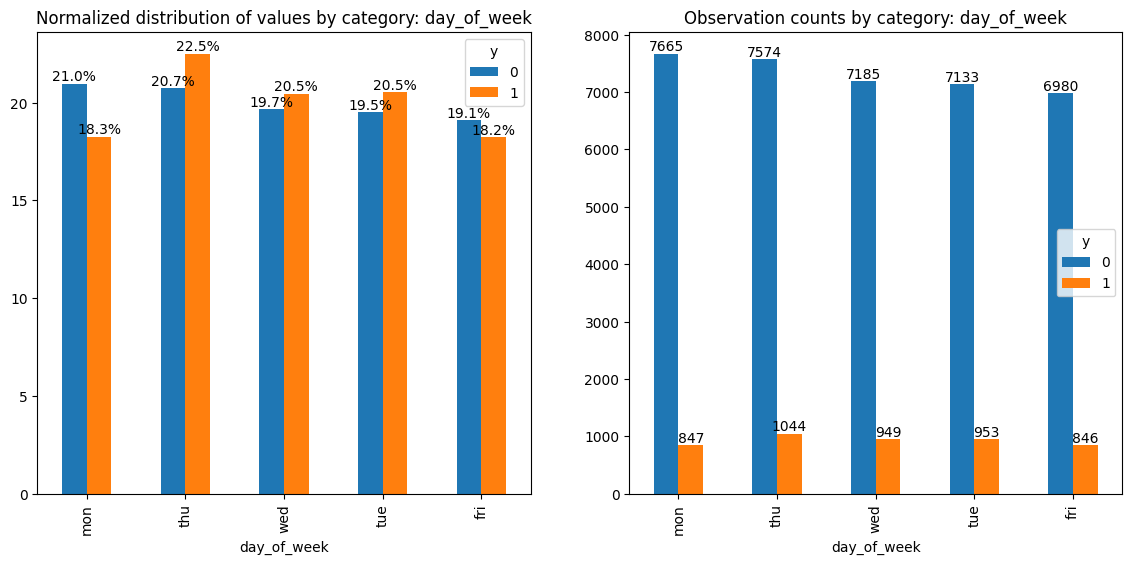

In [ ]:
uni_cat_target_compare(df, 'day_of_week')

***Observations:***

Looking at the histograms, we see that the bank makes roughly the same number of calls every business day. The normalized distribution graph shows that the probability of success (y=1) remains virtually unchanged regardless of the day of the week.

The day_of_week column does not provide any convincing evidence of an effect on the target variable.

#####Feature Insight: month

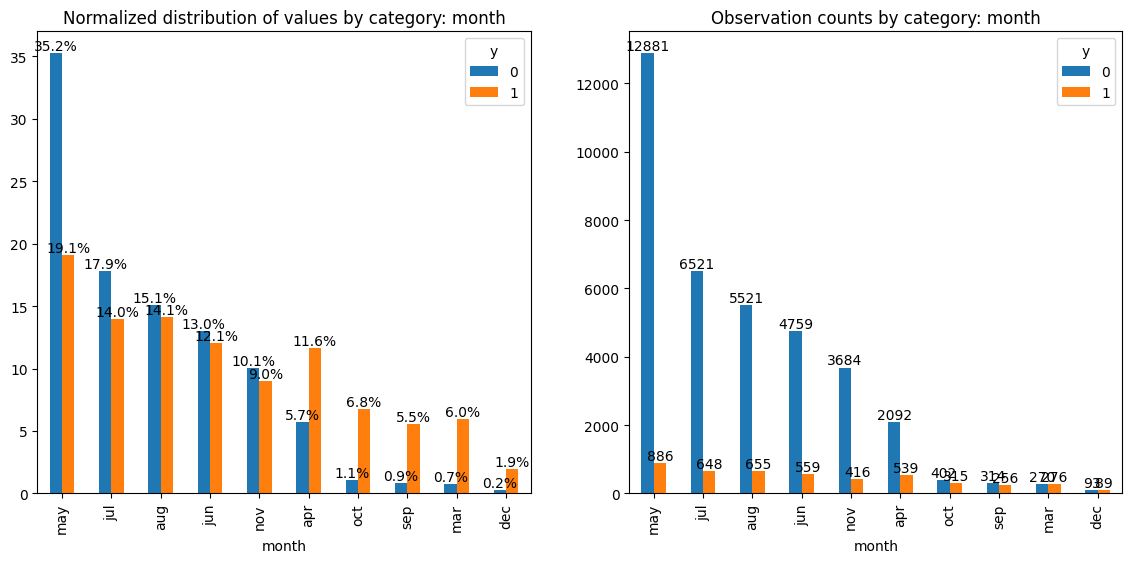

In [ ]:
uni_cat_target_compare(df, 'month')

***Observations:***

The charts show that May is the most intensive month in terms of the bank’s activity, indicating a large-scale spring marketing campaign.

Although the highest number of calls is made in May, the success rate is not the highest. Instead, months such as March, September, October, and December demonstrate significantly higher relative conversion rates.

The month is a strong predictor.


#####Feature Insight: contact

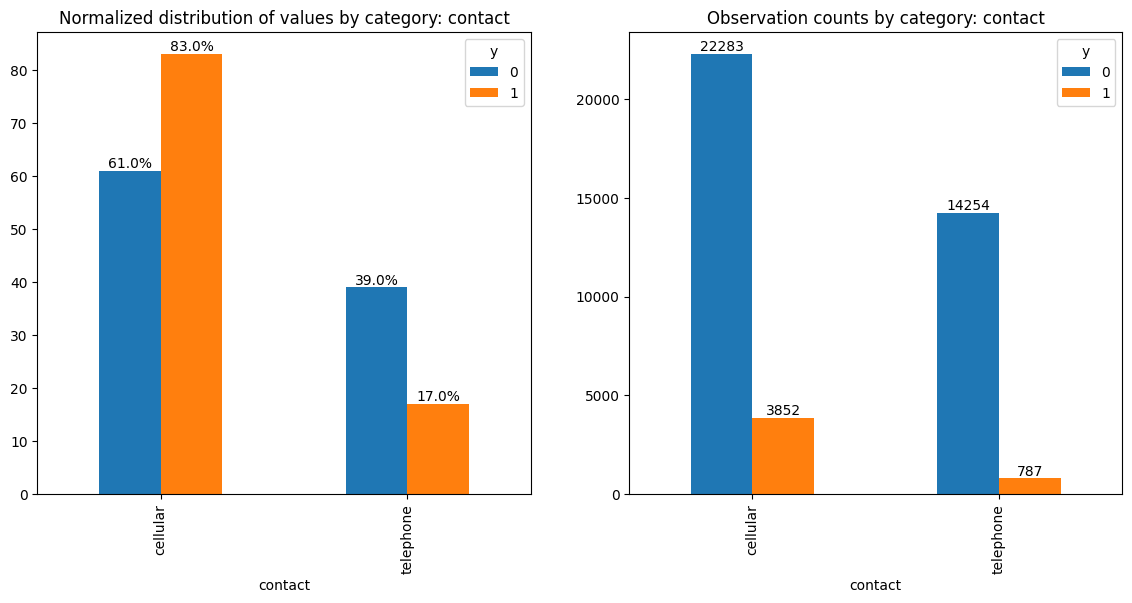

In [ ]:
uni_cat_target_compare(df, 'contact')

***Observations:***

- The charts for “contact” show that the communication channel has a significant impact on the success of the campaign. The charts also indicate that the bank uses mobile (cellular) communication more often than landlines (telephone).
- The normalized distribution graph shows that
the share share of successes (y=1) among mobile phone users accounts for 83% of all successful cases in this category, whereas for landlines, this figure is only 17%. In other words, a call to a mobile phone significantly increases the chances of a positive response from the customer.
- The contact variable is a strong predictor.

#####Feature Insight: loan

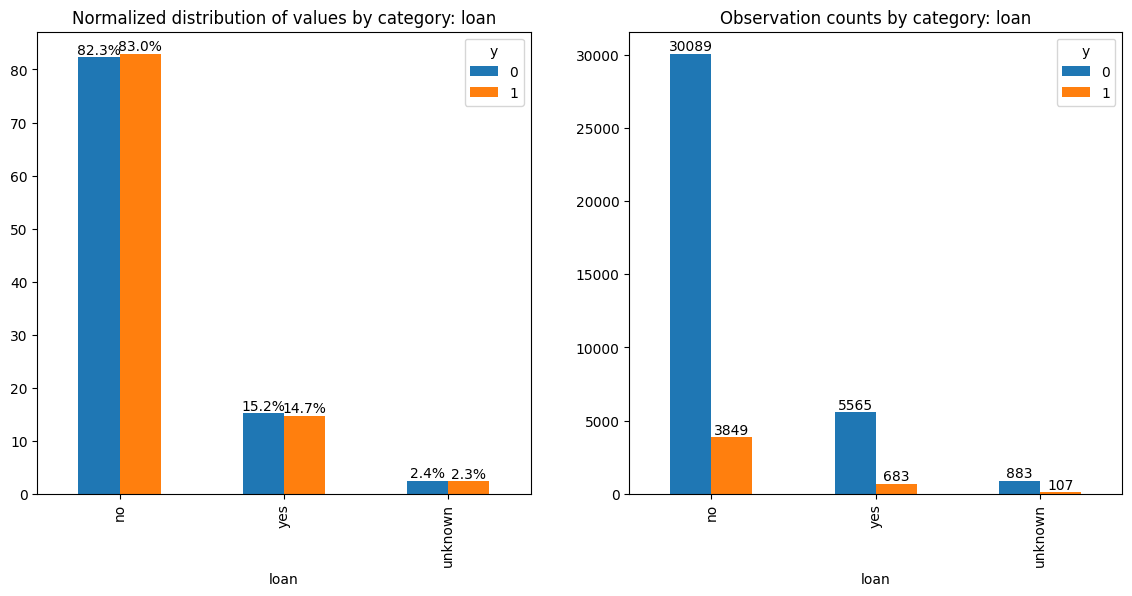

In [ ]:
uni_cat_target_compare(df, 'loan')

***Observations:***

- The normalized graph shows nearly identical proportions of successes and failures for all values of the loan column.

- This column does not provide any convincing evidence of an effect on the target variable.

#####Feature Insight: housing

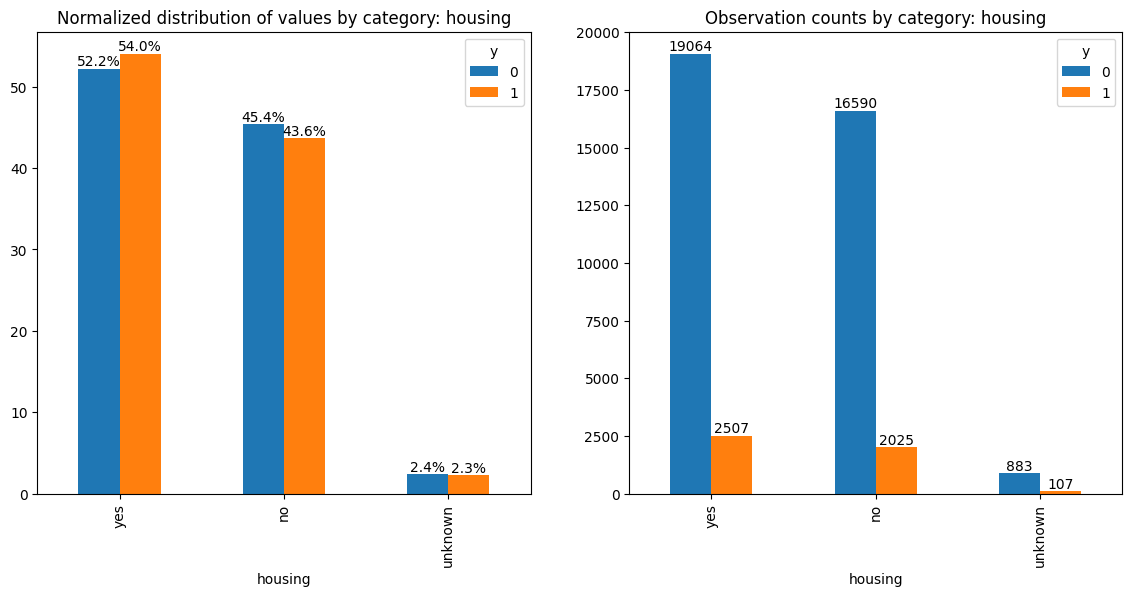

In [ ]:
uni_cat_target_compare(df, 'housing')

***Observations:***

- The normalized graph shows nearly identical proportions of successes and failures for all values of the housing column.

- This column does not provide any convincing evidence of an effect on the target variable.

#####Feature Insight: default

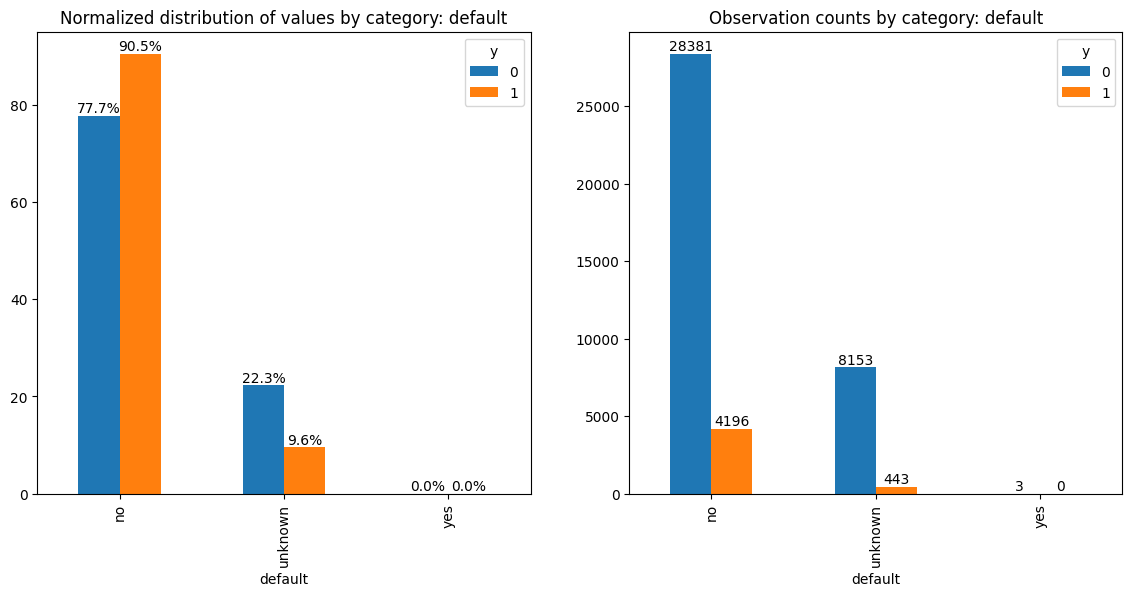

In [ ]:
uni_cat_target_compare(df, 'default')

***Observations:***

- The normalized chart shows that 90.5% of all successful deposit subscriptions come from customers with no outstanding credit debt.
- There is insufficient data for the “yes” category, as a result, the model cannot identify a pattern.
- Therefore, we can conclude that this column does not provide any convincing evidence of an effect on the target variable.

#####Feature Insight: marital

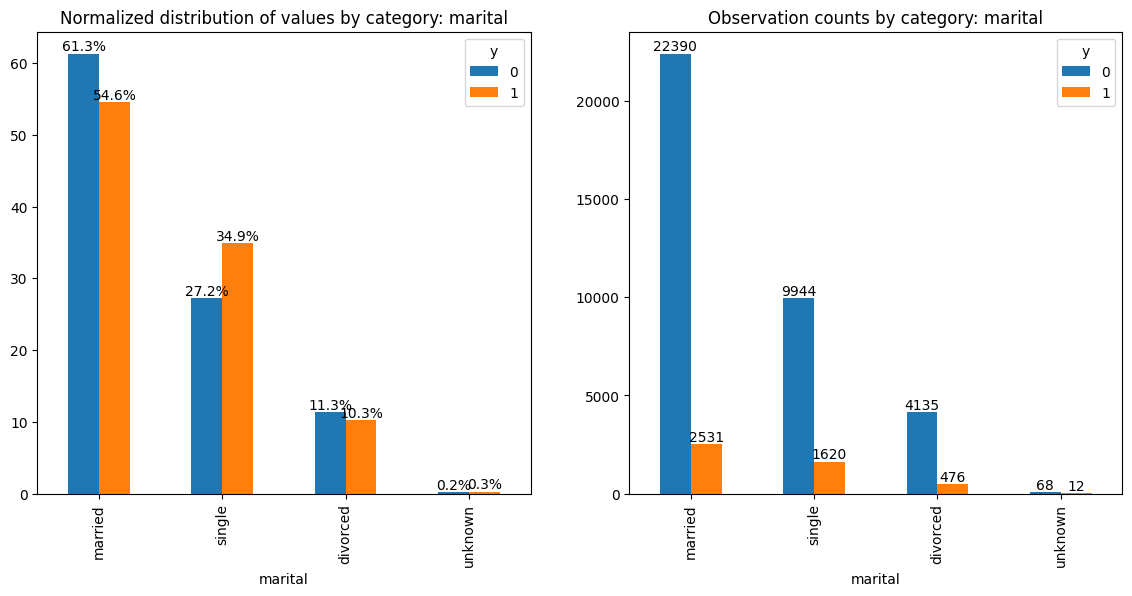

In [ ]:
uni_cat_target_compare(df, 'marital')

***Observations:***
- The Observation Counts chart clearly shows that married individuals make up the largest group of customers.
- Although there are more married customers, the “single” category demonstrates higher relative performance.
- The “marital” variable can be used as a predictor.

#####Feature Insight: education

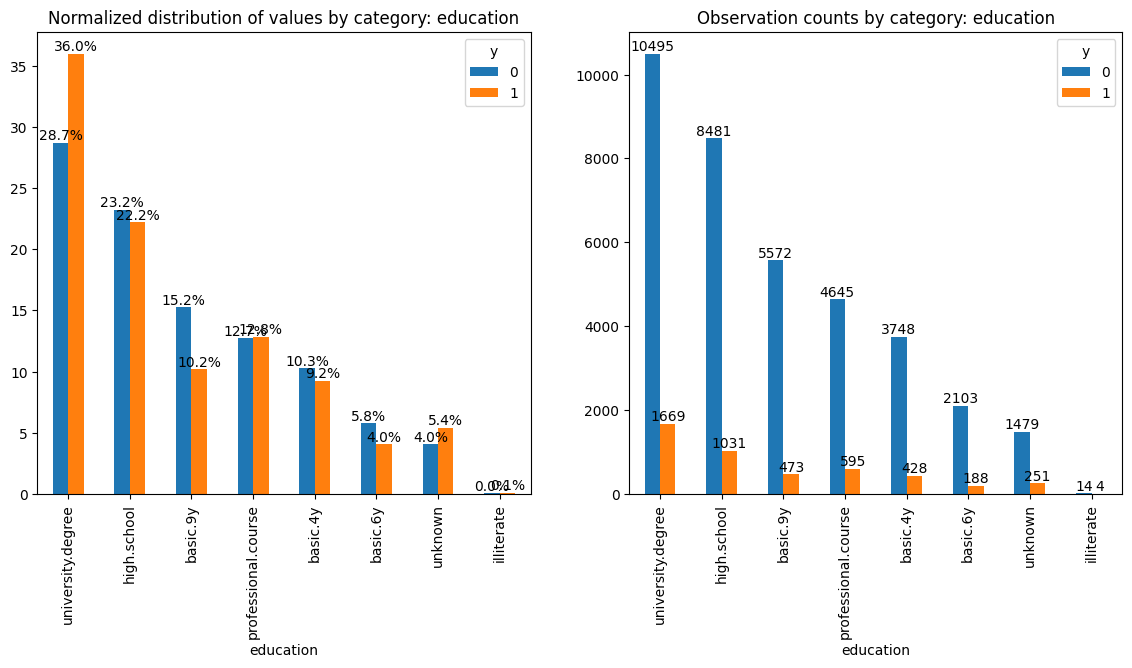

In [ ]:
uni_cat_target_compare(df, 'education')

***Observations:***

- Customers with a university degree constitute the largest group. The second-largest group consists of high school graduates.

- The share of university graduates among successful subscriptions is 36.0%, which is significantly higher than their 28.7% share among failures.

- Higher education is a strong predictor of success. This may indicate a higher level of financial literacy or a more stable income among this group of clients.

#####Feature Insight: job

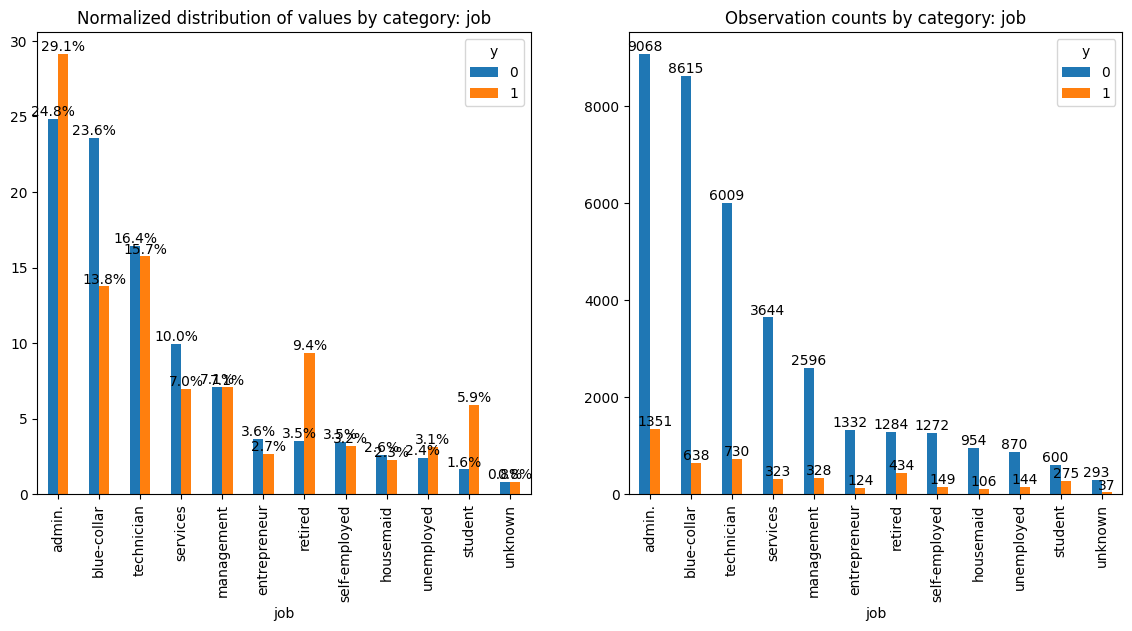

In [ ]:
uni_cat_target_compare(df, 'job')

***Observations:***

- The “Observation counts” chart shows that the bank most frequently interacts with admins and blue-collar workers.

- At the same time, admins have a significantly higher success rate than their failure rate, while blue-collar workers show the opposite trend.
Although the number of students and retirees is small, they demonstrate a high conversion rate.

- The job variable is a strong predictor.


##2.Model Selection and Evaluation Metrics

*Methodology*

Since the task is a binary classification problem with a significant class imbalance (as shown in the EDA), a set of machine learning algorithms was selected to compare the effectiveness of different modeling approaches:

- Logistic Regression serves as a baseline model due to its simplicity and
computational efficiency.

- The k-Nearest Neighbors (kNN) algorithm was included to capture local patterns based on feature similarity.

- Decision Tree was chosen for its ability to model non-linear relationships and provide clear, rule-based decision logic.

- AdaBoost was utilized as a classic adaptive boosting approach that focuses on "hard" instances by adjusting the weights of incorrectly classified samples.

- Gradient boosting (XGBoost, LightGBM) was selected to maximize predictive performance by iteratively correcting the errors of previous models.

*Evaluation Metrics*

Due to the significant imbalance in the target variable, accuracy was rejected as a primary metric, as it can be misleading in imbalanced datasets. Instead, ROC-AUC was chosen as the main evaluation metric to assess the models’ ability to distinguish between classes.

Additionally, the F1-score was used for further evaluation, along with the Precision and Recall, to provide a more detailed understanding of classification errors.

##3.Data Preprocessing

Data cleaning, including duplicate removal and target variable encoding, was performed during the EAD.

###Handling Outliers in Numeric Columns

In [ ]:

def dist_box(dataset, column):
    with warnings.catch_warnings():
      warnings.simplefilter("ignore")

      plt.figure(figsize=(16,6))

      plt.subplot(1,2,1)
      sns.distplot(dataset[column], color = 'purple')
      pltname = 'Distribution plot for ' + column
      plt.ticklabel_format(style='plain', axis='x')
      plt.title(pltname)

      plt.subplot(1,2,2)
      red_diamond = dict(markerfacecolor='r', marker='D')
      sns.boxplot(y = column, data = dataset, flierprops = red_diamond)
      pltname = 'boxplot for ' + column
      plt.title(pltname)

      plt.show()

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000,41176.0000
mean,40.0238,258.3158,2.5679,962.4648,0.1730,0.0819,93.5757,-40.5029,3.6213,5167.0349,0.1127
std,10.4207,259.3053,2.7703,186.9371,0.4950,1.5709,0.5788,4.6279,1.7344,72.2514,0.3162
min,17.0000,0.0000,1.0000,0.0000,0.0000,-3.4000,92.2010,-50.8000,0.6340,4963.6000,0.0000
25%,32.0000,102.0000,1.0000,999.0000,0.0000,-1.8000,93.0750,-42.7000,1.3440,5099.1000,0.0000
50%,38.0000,180.0000,2.0000,999.0000,0.0000,1.1000,93.7490,-41.8000,4.8570,5191.0000,0.0000
75%,47.0000,319.0000,3.0000,999.0000,0.0000,1.4000,93.9940,-36.4000,4.9610,5228.1000,0.0000
max,98.0000,4918.0000,56.0000,999.0000,7.0000,1.4000,94.7670,-26.9000,5.0450,5228.1000,1.0000


####Outlier Analysis of the campaign Feature

In [ ]:
df['campaign'].describe(percentiles = [0.75,0.99,0.999])

,campaign
count,41176.0000
mean,2.5679
std,2.7703
min,1.0000
50%,2.0000
75%,3.0000
99%,14.0000
99.9%,29.0000
max,56.0000



Outlier analysis was performed for all numeric variables.

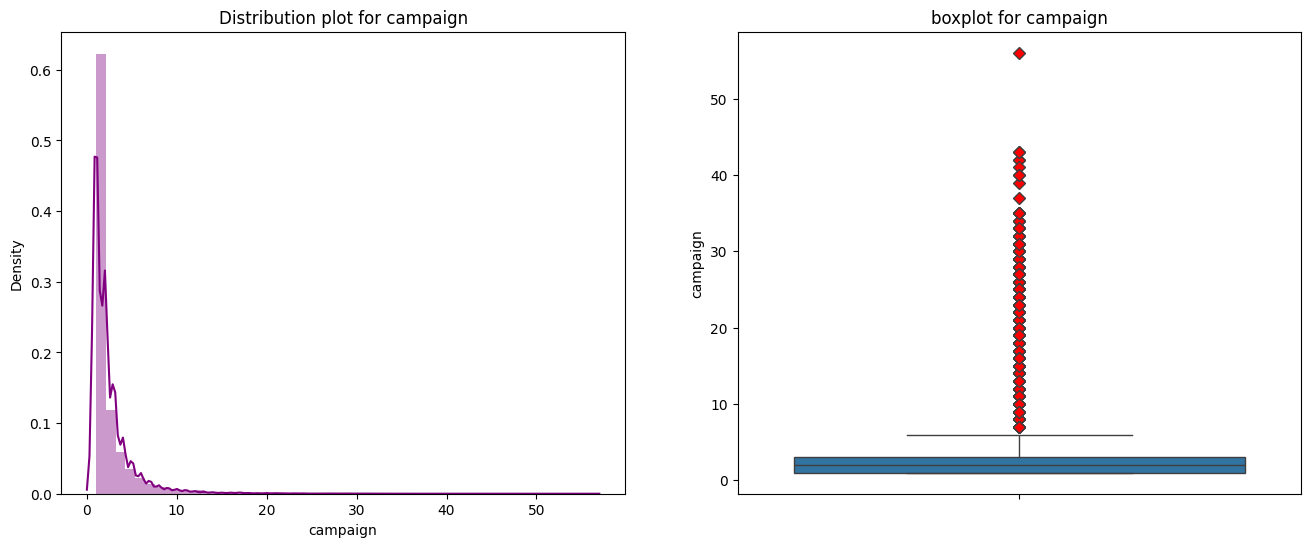

In [ ]:
dist_box(df, 'campaign')

As we can see from the figures, the variable has a significant number of outliers. To reduce the influence of outliers, the variable was capped at the 99th percentile in the function **feature_engineering(file **bank_marketing_campaigns.py**)**, which is applied during the data preparation stage before model training. This approach helps improve model stability while retaining 99% of the original observations unchanged.


###Category Grouping and Feature Engineering

Grouping of categorical features and creation of new features (feature engineering) are implemented in the file **bank_marketing_campaigns.py**, specifically in the function **feature_engineering**, which is applied during the data preparation stage before model training.

##4-5. Model Development and Evaluation

In [ ]:
train_df, val_df, _ = split_and_engineer(df)

data = preprocess_data(train_df, val_df, categorical=True, scaler_numeric=True)
data_tree = preprocess_data(train_df, val_df, categorical=True, scaler_numeric=False)
data_boost = preprocess_data(train_df, val_df, categorical=False, scaler_numeric=False)

X_train = data['train_X']
train_targets = data['train_y']
X_val = data['val_X']
val_targets = data['val_y']


X_train_tree = data_tree['train_X']
train_targets_tree = data_tree['train_y']
X_val_tree = data_tree['val_X']
val_targets_tree = data_tree['val_y']

X_train_boost = data_boost['train_X']
train_targets_boost = data_boost['train_y']
X_val_boost = data_boost['val_X']
val_targets_boost = data_boost['val_y']


In [ ]:
X_train_boost.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32940 entries, 36444 to 24783
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             32940 non-null  float64 
 1   campaign        32940 non-null  float64 
 2   previous        32940 non-null  float64 
 3   emp.var.rate    32940 non-null  float64 
 4   cons.price.idx  32940 non-null  float64 
 5   cons.conf.idx   32940 non-null  float64 
 6   euribor3m       32940 non-null  float64 
 7   nr.employed     32940 non-null  float64 
 8   education_rank  32940 non-null  float64 
 9   is_contacted    32940 non-null  float64 
 10  marital         32940 non-null  category
 11  default         32940 non-null  category
 12  housing         32940 non-null  category
 13  loan            32940 non-null  category
 14  contact         32940 non-null  category
 15  month           32940 non-null  category
 16  poutcome        32940 non-null  category
 17  job_grouped  

In [ ]:
cat_col = X_train_boost.select_dtypes('category').columns
cat_col

Index(['marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome',
       'job_grouped', 'age_category'],
      dtype='object')

In [ ]:
cat_feature_indexes = [X_train_boost.columns.get_loc(col) for col in cat_col]
cat_feature_indexes

[10, 11, 12, 13, 14, 15, 16, 17, 18]

In [ ]:
X_train.head()

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,education_rank,is_contacted,marital_divorced,marital_married,marital_single,marital_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_nonexistent,poutcome_success,job_grouped_blue-collar,job_grouped_office worker,job_grouped_retired,job_grouped_self-employed,job_grouped_student,job_grouped_unemployed,job_grouped_unknown,age_category_0-20,age_category_20-30,age_category_30-40,age_category_40-50,age_category_50-60,age_category_60-70,age_category_70+
36444,-1.5323,-0.2159,1.6571,-1.8964,-1.0572,-0.0627,-1.3572,-1.2529,0.4882,-0.1950,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1233,-0.7670,-0.6533,-0.3486,0.6490,0.7220,0.8878,0.7126,0.3328,0.4882,-0.1950,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
24104,-0.6713,-0.6533,-0.3486,-0.1146,-0.6482,-0.3219,0.3612,0.3991,1.3207,-0.1950,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
15513,-0.1930,0.6589,-0.3486,0.8399,0.5909,-0.4731,0.7713,0.8453,-1.1769,-0.1950,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
17912,-0.0973,0.6589,-0.3486,0.8399,0.5909,-0.4731,0.7736,0.8453,-0.3444,-0.1950,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000


In [ ]:
X_train_tree.head()

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,education_rank,is_contacted,marital_divorced,marital_married,marital_single,marital_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_nonexistent,poutcome_success,job_grouped_blue-collar,job_grouped_office worker,job_grouped_retired,job_grouped_self-employed,job_grouped_student,job_grouped_unemployed,job_grouped_unknown,age_category_0-20,age_category_20-30,age_category_30-40,age_category_40-50,age_category_50-60,age_category_60-70,age_category_70+
36444,24.0000,2.0000,1.0000,-2.9000,92.9630,-40.8000,1.2620,5076.2000,3.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1233,32.0000,1.0000,0.0000,1.1000,93.9940,-36.4000,4.8550,5191.0000,3.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
24104,33.0000,1.0000,0.0000,-0.1000,93.2000,-42.0000,4.2450,5195.8000,4.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
15513,38.0000,4.0000,0.0000,1.4000,93.9180,-42.7000,4.9570,5228.1000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
17912,39.0000,4.0000,0.0000,1.4000,93.9180,-42.7000,4.9610,5228.1000,2.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000


In [ ]:
X_train_boost.head()

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,education_rank,is_contacted,marital,default,housing,loan,contact,month,poutcome,job_grouped,age_category
36444,24.0000,2.0000,1.0000,-2.9000,92.9630,-40.8000,1.2620,5076.2000,3.0000,0.0000,single,no,no,no,cellular,jun,failure,office worker,20-30
1233,32.0000,1.0000,0.0000,1.1000,93.9940,-36.4000,4.8550,5191.0000,3.0000,0.0000,married,no,no,no,telephone,may,nonexistent,blue-collar,30-40
24104,33.0000,1.0000,0.0000,-0.1000,93.2000,-42.0000,4.2450,5195.8000,4.0000,0.0000,single,no,no,no,telephone,nov,nonexistent,self-employed,30-40
15513,38.0000,4.0000,0.0000,1.4000,93.9180,-42.7000,4.9570,5228.1000,1.0000,0.0000,married,no,no,yes,telephone,jul,nonexistent,self-employed,30-40
17912,39.0000,4.0000,0.0000,1.4000,93.9180,-42.7000,4.9610,5228.1000,2.0000,0.0000,married,no,yes,yes,cellular,jul,nonexistent,blue-collar,30-40


In [ ]:
RANDOM_STATE = 42

models_dict = {
               'Logistic Regression' : LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, class_weight='balanced'),
               'kNN' : KNeighborsClassifier(),
               'Decision Tree' : DecisionTreeClassifier(
                                          random_state=RANDOM_STATE,
                                          class_weight='balanced',
                                          max_depth=5,
                                          min_samples_leaf=20
                                          ),

               'AdaBoost' : AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'), n_estimators=50, learning_rate=1, random_state=RANDOM_STATE),

               'XGBoost' : xgb.XGBClassifier(
                                          max_depth=3,
                                          n_estimators=100,
                                          scale_pos_weight=8,
                                          enable_categorical=True,
                                          missing=np.nan,
                                          random_state=RANDOM_STATE,
                                          eval_metric='auc',
                                          #device='cuda'
                                      ),

              'LightGBM' : lgb.LGBMClassifier(
                                          max_depth=3,
                                          n_estimators=50,
                                          learning_rate=0.1,
                                          scale_pos_weight=8,
                                          cat_feature=cat_feature_indexes,
                                          missing=np.nan,
                                          #device='cuda'
                                          random_state=RANDOM_STATE,
                                          verbose=-1,
                                          eval_metric='auc',
                                      )

            }

all_metrics_list = []
trained_models = {}

for name, model in models_dict.items():

    if name in ("XGBoost", "LightGBM"):
        if name == "XGBoost":
          model.fit(X_train_boost, train_targets_boost, eval_set=[(X_val_boost, val_targets_boost)], verbose=False)
        else:
          model.fit(X_train_boost, train_targets_boost, eval_set=[(X_val_boost, val_targets_boost)])

        trained_models[name] = (model, X_val_boost, val_targets_boost)
        train_metrics = evaluate_model(X_train_boost, train_targets_boost, model, name)
        train_metrics['dataset'] = 'train'
        val_metrics = evaluate_model(X_val_boost, val_targets_boost, model, name)
        val_metrics['dataset'] = 'validation'

    elif name == "Decision Tree":
        model.fit(X_train_tree, train_targets_tree)
        trained_models[name] = (model, X_val_tree, val_targets_tree)
        train_metrics = evaluate_model(X_train_tree, train_targets_tree, model, name)
        train_metrics['dataset'] = 'train'
        val_metrics = evaluate_model(X_val_tree, val_targets_tree, model, name)
        val_metrics['dataset'] = 'validation'

    else:
        model.fit(X_train, train_targets)
        trained_models[name] = (model, X_val, val_targets)
        train_metrics = evaluate_model(X_train, train_targets, model, name)
        train_metrics['dataset'] = 'train'
        val_metrics = evaluate_model(X_val, val_targets, model, name)
        val_metrics['dataset'] = 'validation'

    all_metrics_list.append(train_metrics)
    all_metrics_list.append(val_metrics)

results_df = pd.concat(all_metrics_list, ignore_index=True)

cols = ['model', 'dataset', 'roc_auc', 'f1_score', 'precision', 'recall']
results_df = results_df.reindex(columns=cols)

display(results_df)

,model,dataset,roc_auc,f1_score,precision,recall
0,Logistic Regression,train,0.7943,0.4530,0.3561,0.6222
1,Logistic Regression,validation,0.7987,0.4642,0.3624,0.6455
2,kNN,train,0.9246,0.4901,0.7048,0.3756
3,kNN,validation,0.7439,0.3832,0.5493,0.2942
4,Decision Tree,train,0.7843,0.4697,0.3824,0.6087
5,Decision Tree,validation,0.7906,0.4819,0.3900,0.6304
6,AdaBoost,train,0.6987,0.4567,0.4409,0.4737
7,AdaBoost,validation,0.7065,0.4729,0.4615,0.4849
8,XGBoost,train,0.8365,0.4785,0.3772,0.6540
9,XGBoost,validation,0.8103,0.4824,0.3832,0.6509


In [ ]:
display(results_df[results_df['dataset'] == 'train'].style.highlight_max(axis=0, color='green'))

,model,dataset,roc_auc,f1_score,precision,recall
0,Logistic Regression,train,0.794319,0.452967,0.356107,0.622204
2,kNN,train,0.924648,0.490069,0.704752,0.375640
4,Decision Tree,train,0.784272,0.469695,0.382363,0.608731
6,AdaBoost,train,0.698733,0.456742,0.440933,0.473727
8,XGBoost,train,0.836509,0.478462,0.377215,0.654002
10,LightGBM,train,0.805346,0.467338,0.370963,0.631366


In [ ]:
display(results_df[results_df['dataset'] == 'validation'].style.highlight_max(axis=0, color='green'))

,model,dataset,roc_auc,f1_score,precision,recall
1,Logistic Regression,validation,0.798730,0.464161,0.362371,0.645474
3,kNN,validation,0.743877,0.383158,0.549296,0.294181
5,Decision Tree,validation,0.790561,0.481878,0.390000,0.630388
7,AdaBoost,validation,0.706537,0.472937,0.461538,0.484914
9,XGBoost,validation,0.810291,0.482428,0.383249,0.650862
11,LightGBM,validation,0.808676,0.475365,0.374767,0.649784


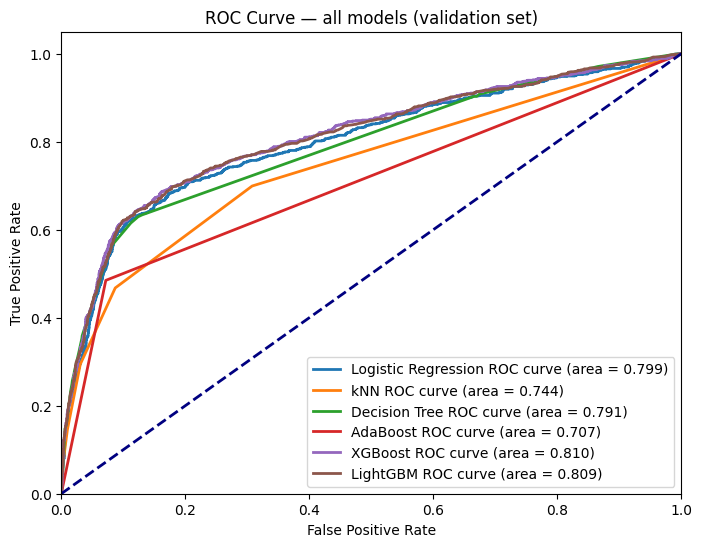

In [ ]:
predict_and_plot_roc_auc_all(trained_models)

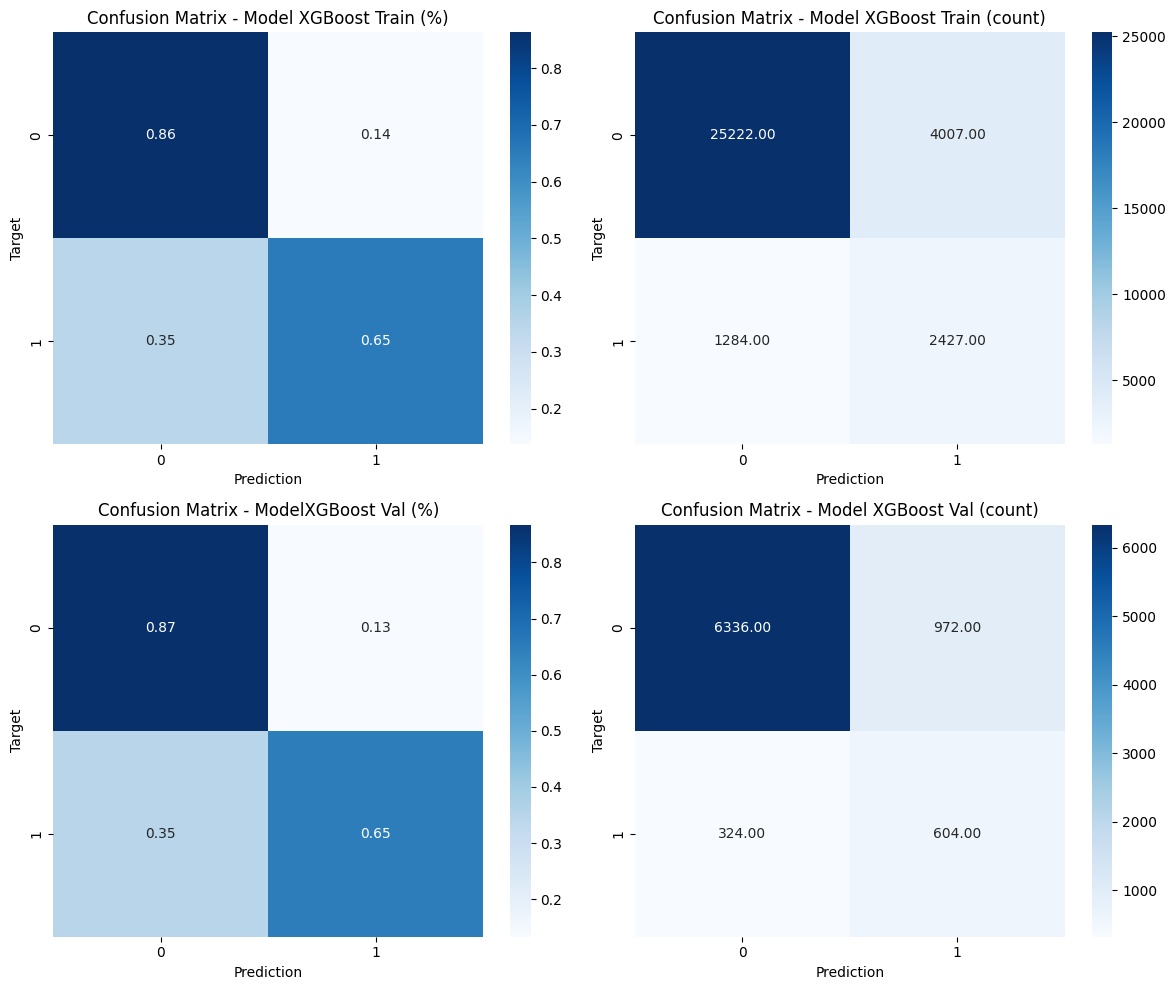

In [ ]:
plot_one_model_cf(
    X_train_boost, train_targets_boost,
    X_val_boost, val_targets_boost,
    models_dict['XGBoost'],
    model_name='XGBoost'
)

***Observations:***
- Logistic Regression: The model produced decent, stable results without overfitting.
- kNN: The model performs very well on the training set but significantly worse on the validation set, which indicates overfitting.
- Decision Tree: The model has balanced results without overfitting, with a strong F1 score on the validation set — second best after XGBoost.
- AdaBoost:  The model shows the lowest performance among all evaluated models, despite stable results without overfitting.
- XGBoost: The model performed very well and is the best among the set of built models.
- LightGBM: The model performed very well, almost as well as XGBoost.

Overall, XGBoost is recommended as the primary model due to its highest ROC AUC value on the validation set, with no signs of overfitting. LightGBM is a viable alternative. Since the goal is to identify customers who are likely to open a term deposit, the recall metric is particularly important. From this perspective, the XGBoost and LightGBM models demonstrate the best recall among models without overfitting.

To further enhance the XGBoost and LightGBM models, hyperparameter tuning should be conducted.

##6.Hyperparameter Tuning

Let's tune the hyperparameters for the XGBoost and LightGBM models.

###Sklearn: Randomized Search

In [ ]:
base_model_xgb = xgb.XGBClassifier(
                                          max_depth=3,
                                          n_estimators=100,
                                          scale_pos_weight=8,
                                          enable_categorical=True,
                                          missing=np.nan,
                                          random_state=RANDOM_STATE,
                                          eval_metric='auc',
                                          #device='cuda'
                                      )

params_xgb = {
    'max_depth':        np.arange(3, 8, 1),
    'n_estimators':     np.arange(100, 400, 100),
    'learning_rate':    np.round(np.arange(0.01, 0.21, 0.05), 2),
    'scale_pos_weight': np.arange(6, 11, 1),
    'subsample':        np.round(np.arange(0.7, 1.05, 0.1), 1),
}

search_xgb = RandomizedSearchCV(
    base_model_xgb,
    params_xgb,
    n_iter = 100,
    cv=3,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search_xgb.fit(X_train_boost, train_targets_boost, eval_set=[(X_val_boost, val_targets_boost)], verbose=False)
models_dict['XGBoost_Randomized_Search'] = search_xgb.best_estimator_
print("Best params:", search_xgb.best_params_)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best params: {'subsample': np.float64(0.8), 'scale_pos_weight': np.int64(6), 'n_estimators': np.int64(200), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.06)}


In [ ]:
base_model_lgb =  lgb.LGBMClassifier(
                                          max_depth=3,
                                          n_estimators=50,
                                          learning_rate=0.1,
                                          scale_pos_weight=8,
                                          cat_feature=cat_feature_indexes,
                                          missing=np.nan,
                                          #device='cuda'
                                          random_state=RANDOM_STATE,
                                          verbose=-1,
                                          eval_metric='auc',
                                      )

params_lgb = {
    'num_leaves':       np.arange(20, 110, 20),
    'max_depth':        np.arange(3, 8, 1),
    'n_estimators':     np.arange(100, 400, 100),
    'learning_rate':    np.round(np.arange(0.01, 0.21, 0.05), 2),
    'scale_pos_weight': np.arange(6, 11, 1),
    'subsample':        np.round(np.arange(0.7, 1.05, 0.1), 1),
}

search_lgb = RandomizedSearchCV(
    base_model_lgb,
    params_lgb,
    n_iter=100,
    cv=3,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search_lgb.fit(X_train_boost, train_targets_boost, eval_set=[(X_val_boost, val_targets_boost)])
models_dict['LightGBM_Randomized_Search'] = search_lgb.best_estimator_
print("Best params:", search_lgb.best_params_)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best params: {'subsample': np.float64(0.9), 'scale_pos_weight': np.int64(7), 'num_leaves': np.int64(60), 'n_estimators': np.int64(200), 'max_depth': np.int64(5), 'learning_rate': np.float64(0.01)}


In [ ]:
subset_models = {
    'XGBoost_Randomized_Search': models_dict['XGBoost_Randomized_Search'],
    'LightGBM_Randomized_Search': models_dict['LightGBM_Randomized_Search']
}
results_df, trained_models = update_metrics_dict(subset_models, X_train_boost, X_val_boost, train_targets_boost, val_targets_boost, results_df, trained_models)

###Hyperopt: Bayesian Optimization

In [ ]:
def objective_xgb(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        scale_pos_weight=params['scale_pos_weight'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        enable_categorical=True,
        missing=np.nan,
        random_state=RANDOM_STATE,
        eval_metric='auc',
        #device='cuda',
    )

    clf.fit(
        X_train_boost,
        train_targets_boost,
        eval_set=[(X_val_boost, val_targets_boost)],
        verbose=False)

    probs = clf.predict_proba(X_val_boost)[:, 1]
    auc = roc_auc_score(val_targets_boost, probs)

    return {'loss': -auc, 'status': STATUS_OK}

space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 1, 20, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'scale_pos_weight': hp.quniform('scale_pos_weight', 6, 11, 1),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}


trials = Trials()
best = fmin(fn=objective_xgb, space=space, algo=tpe.suggest, max_evals=50, trials=trials, rstate=np.random.default_rng(RANDOM_STATE))

best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("The best hyperparameters: ", best)

xgb_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    scale_pos_weight=int(best['scale_pos_weight']),
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    #device='cuda',
)

xgb_clf.fit(X_train_boost, train_targets_boost,
              eval_set=[(X_val_boost, val_targets_boost)],
              verbose=False)
models_dict['XGBoost_Hyperopt'] = xgb_clf

100%|██████████| 50/50 [02:48<00:00,  3.38s/trial, best loss: -0.8142323510607177]
The best hyperparameters:  {'colsample_bytree': np.float64(0.9978584031045037), 'gamma': np.float64(0.017864276781270144), 'learning_rate': np.float64(0.012987698134006489), 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 250, 'reg_alpha': np.float64(0.6047461163930593), 'reg_lambda': np.float64(0.3572254498403834), 'scale_pos_weight': np.float64(6.0), 'subsample': np.float64(0.8163412561863207)}


In [ ]:
def objective_lgb(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        num_leaves=int(params['num_leaves']),
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        scale_pos_weight=params['scale_pos_weight'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        cat_feature=cat_feature_indexes,
        missing=np.nan,
        random_state=RANDOM_STATE,
        eval_metric='auc',
        verbose=-1,
    )

    clf.fit(
        X_train_boost,
        train_targets_boost,
        eval_set=[(X_val_boost, val_targets_boost)],
    )

    probs = clf.predict_proba(X_val_boost)[:, 1]
    auc = roc_auc_score(val_targets_boost, probs)

    return {'loss': -auc, 'status': STATUS_OK}

space_lgb = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth':        hp.quniform('max_depth', 1, 20, 1),
    'num_leaves':       hp.quniform('num_leaves', 20, 100, 10),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample':        hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'scale_pos_weight': hp.quniform('scale_pos_weight', 6, 11, 1),
    'reg_alpha':        hp.uniform('reg_alpha', 0, 1),
    'reg_lambda':       hp.uniform('reg_lambda', 0, 1),
}

trials_lgb = Trials()
best_lgb = fmin(fn=objective_lgb, space=space_lgb, algo=tpe.suggest, max_evals=50, trials=trials_lgb, rstate=np.random.default_rng(RANDOM_STATE))

best_lgb['n_estimators'] = int(best_lgb['n_estimators'])
best_lgb['max_depth'] = int(best_lgb['max_depth'])
best_lgb['num_leaves'] = int(best_lgb['num_leaves'])
best_lgb['min_child_weight'] = int(best_lgb['min_child_weight'])

print("The best hyperparameters:", best_lgb)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=best_lgb['n_estimators'],
    learning_rate=best_lgb['learning_rate'],
    max_depth=best_lgb['max_depth'],
    num_leaves=best_lgb['num_leaves'],
    min_child_weight=best_lgb['min_child_weight'],
    subsample=best_lgb['subsample'],
    colsample_bytree=best_lgb['colsample_bytree'],
    scale_pos_weight=int(best_lgb['scale_pos_weight']),
    reg_alpha=best_lgb['reg_alpha'],
    reg_lambda=best_lgb['reg_lambda'],
    cat_feature=cat_feature_indexes,
    missing=np.nan,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    verbose=-1,
)

lgb_clf.fit(X_train_boost, train_targets_boost,
            eval_set=[(X_val_boost, val_targets_boost)])

models_dict['LightGBM_Hyperopt'] = lgb_clf

100%|██████████| 50/50 [01:48<00:00,  2.18s/trial, best loss: -0.8129698588462337]
The best hyperparameters: {'colsample_bytree': np.float64(0.5979787164163574), 'learning_rate': np.float64(0.01008188859815991), 'max_depth': 10, 'min_child_weight': 4, 'n_estimators': 400, 'num_leaves': 50, 'reg_alpha': np.float64(0.8406739971812087), 'reg_lambda': np.float64(0.9260991565100177), 'scale_pos_weight': np.float64(7.0), 'subsample': np.float64(0.9171337650702867)}


In [ ]:
subset_models_2 = {
    'XGBoost_Hyperopt': models_dict['XGBoost_Hyperopt'],
    'LightGBM_Hyperopt': models_dict['LightGBM_Hyperopt']
}
results_df, trained_models = update_metrics_dict(subset_models_2, X_train_boost, X_val_boost, train_targets_boost, val_targets_boost, results_df, trained_models)
display(results_df)

,model,dataset,roc_auc,f1_score,precision,recall
0,Logistic Regression,train,0.7943,0.4530,0.3561,0.6222
1,Logistic Regression,validation,0.7987,0.4642,0.3624,0.6455
2,kNN,train,0.9246,0.4901,0.7048,0.3756
3,kNN,validation,0.7439,0.3832,0.5493,0.2942
4,Decision Tree,train,0.7843,0.4697,0.3824,0.6087
5,Decision Tree,validation,0.7906,0.4819,0.3900,0.6304
6,AdaBoost,train,0.6987,0.4567,0.4409,0.4737
7,AdaBoost,validation,0.7065,0.4729,0.4615,0.4849
8,XGBoost,train,0.8365,0.4785,0.3772,0.6540
9,XGBoost,validation,0.8103,0.4824,0.3832,0.6509


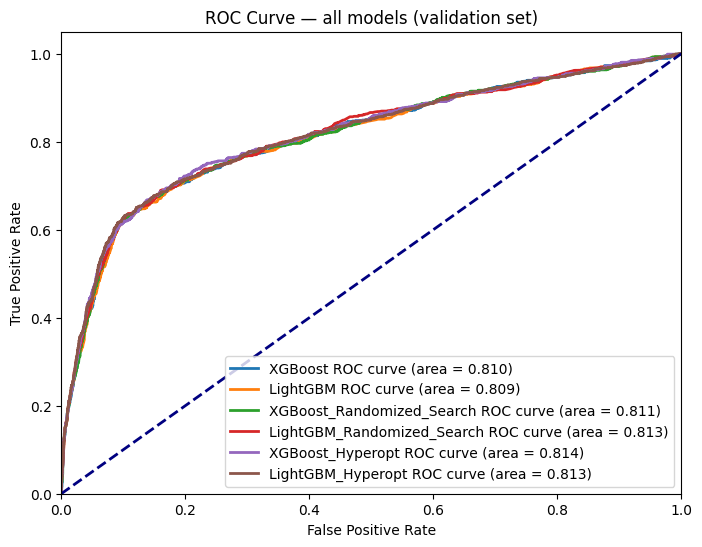

In [ ]:
selected_models = {k: trained_models[k] for k in [
    'XGBoost',
    'LightGBM',
    'XGBoost_Randomized_Search',
    'LightGBM_Randomized_Search',
    'XGBoost_Hyperopt',
    'LightGBM_Hyperopt',
]}

predict_and_plot_roc_auc_all(selected_models)

In [ ]:
selected_model_names = [
                    'XGBoost',
                    'LightGBM',
                    'XGBoost_Randomized_Search',
                    'LightGBM_Randomized_Search',
                    'XGBoost_Hyperopt',
                    'LightGBM_Hyperopt',
  ]

display(results_df[(results_df['model'].isin(selected_model_names)) & (results_df['dataset'] == 'validation')].style.highlight_max(axis=0, color='green'))

,model,dataset,roc_auc,f1_score,precision,recall
9,XGBoost,validation,0.810291,0.482428,0.383249,0.650862
11,LightGBM,validation,0.808676,0.475365,0.374767,0.649784
13,XGBoost_Randomized_Search,validation,0.810877,0.508047,0.425966,0.629310
15,LightGBM_Randomized_Search,validation,0.813270,0.521340,0.454037,0.612069
17,XGBoost_Hyperopt,validation,0.814232,0.515660,0.445490,0.612069
19,LightGBM_Hyperopt,validation,0.812970,0.508855,0.424658,0.634698


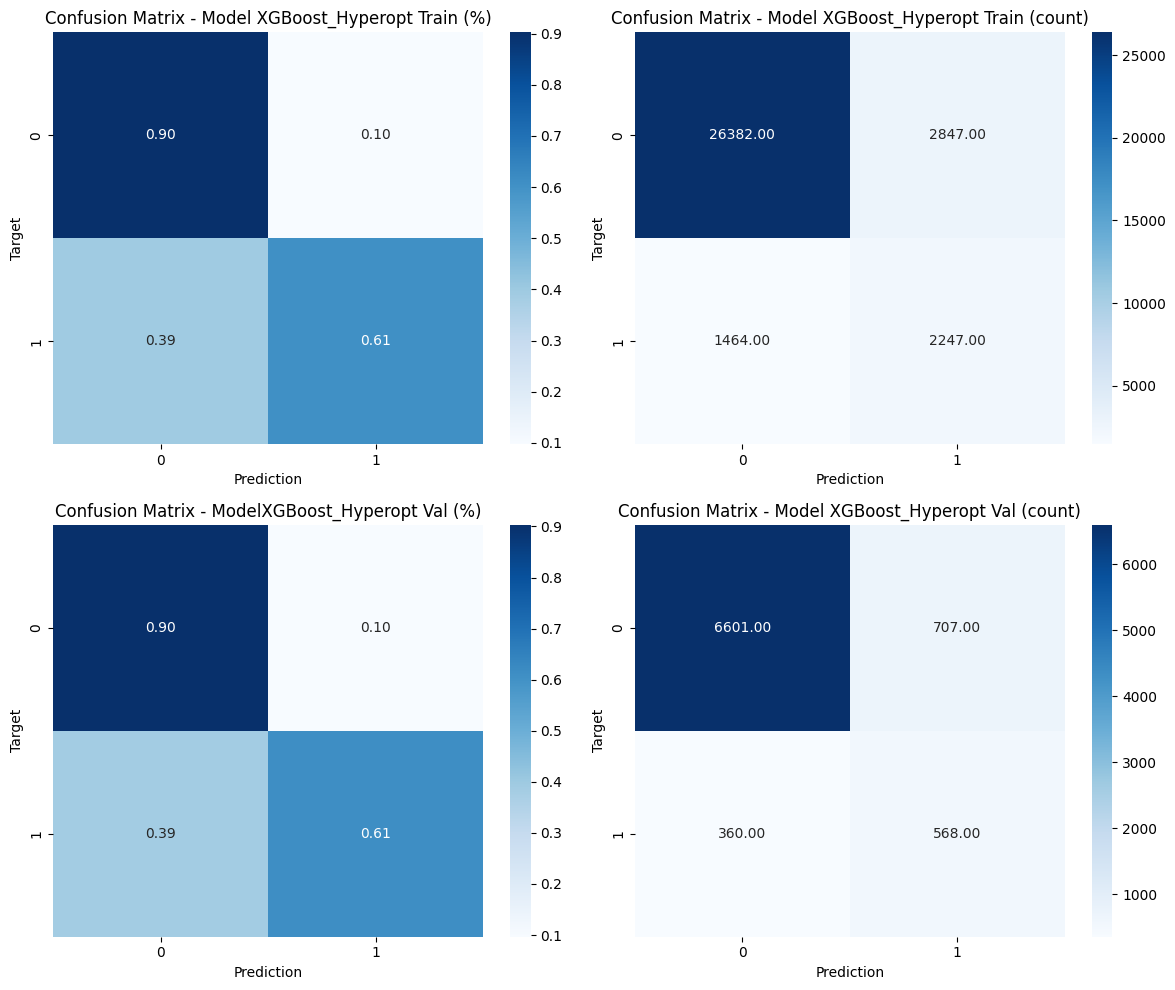

In [ ]:
plot_one_model_cf(
    X_train_boost, train_targets_boost,
    X_val_boost, val_targets_boost,
    models_dict['XGBoost_Hyperopt'],
    model_name='XGBoost_Hyperopt'
)

***Observations:***
- Sklearn Randomized Search:

        XGBoost: showed a slight improvement in both ROC-AUC and F1-score compared to the baseline configuration;

        LightGBM: slight improvement in ROC-AUC, best F1-score among all models;

- Hyperopt (Bayesian Optimization):

        XGBoost: achieved the best ROC-AUC across all evaluated models on the validation set, with stable performance and no signs of overfitting;

        LightGBM: marginal decrease in ROC-AUC compared to Randomized Search, but best Recall among all tuned models.
  
XGBoost_Hyperopt is recommended as the primary model based on the highest validation ROC-AUC. However, it should be noted that tuning the hyperparameters improved the ROC-AUC and F1-score for both models, but this came at the expense of a lower Recall.  If minimizing the number of missed customers is a priority, the base XGBoost model remains the best alternative due to its highest Recall among all models.



##7.Feature Importance

Let’s calculate the feature importance for the selected XGBoost_Hyperopt model.


In [ ]:
importance_df = pd.DataFrame({
    'feature': X_train_boost.columns,
    'importance': models_dict['XGBoost_Hyperopt'].feature_importances_
}).sort_values('importance', ascending=False)

importance_df.style.background_gradient(subset='importance', cmap='Blues_r')

,feature,importance
7,nr.employed,0.687046
15,month,0.054321
9,is_contacted,0.047987
14,contact,0.028558
6,euribor3m,0.023182
5,cons.conf.idx,0.021838
16,poutcome,0.020425
3,emp.var.rate,0.019177
11,default,0.018861
18,age_category,0.010860


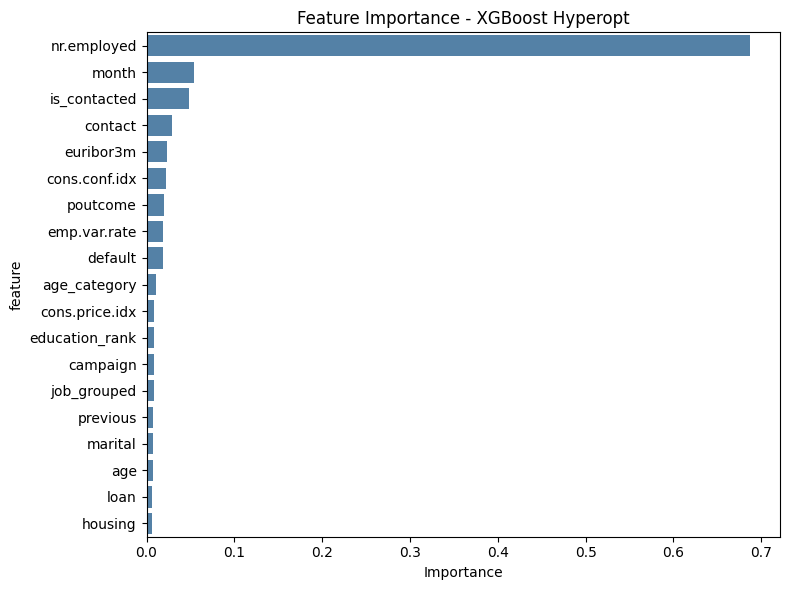

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x='importance', y='feature', color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - XGBoost Hyperopt')
plt.tight_layout()
plt.show()

***Observations:***

The most influential factors are macroeconomic indicators, seasonality and customer interaction metrics.

- First in order of importance is "nr.employed" - Number of employed persons
(quarterly indicator, numerical variable). This feature shows a negative relationship with the target variable, indicating that higher employment levels are associated with a lower predicted probability of term deposit subscription.

- The second most important indicator is "month". This is confirmed by EDA, as different months have different conversion rates.

- Other macroeconomic indicators (Euribor 3M, EMP.VAR.RATE, CONS.CONF.INDEX, CONS.PRICE.INDEX) are important features for the model.

- Indicators of interaction with the client (is_contacted, contact, campaign, previous, poutcome) reflect the history and frequency of contact with the customer. Their importance here is to be expected, since previous interaction history and the number of contacts can influence  the customer’s decision.

- The sociodemographic characteristics (age, age_category, education_rank, job_grouped, marital) have a moderate or low impact.

- Indicators of the client's financial condition (loan, housing, default) are of relatively low importance.


Taking all this into account, we can conclude that the ranking of the characteristics’ importance is, on the whole, appropriate and reasonable.

##8.SHAP Feature Analysis

In [ ]:
model = models_dict['XGBoost_Hyperopt']
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_boost)

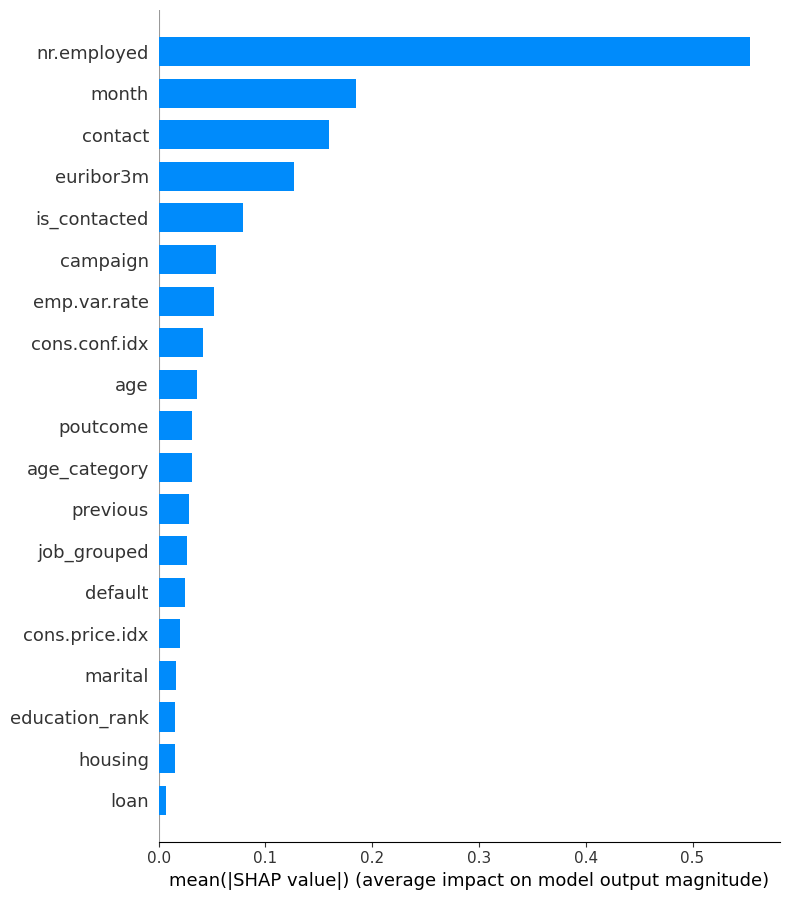

In [ ]:
shap.summary_plot(shap_values, X_train_boost, plot_type="bar")

***Observations:***

Top 5 most important features:
- nr.employed (0.55)
- month (0.18)
- contact (0.16)
- euribor3m (0.13)
- is_contacted  (0.08)

Features ranging from campaign to loan have very low influence (< 0.06) — they have almost no impact on the model’s decision.

In [ ]:
shap_df = pd.DataFrame(shap_values, columns=X_train_boost.columns)
shap_df.abs().mean().sort_values(ascending=False)

,0
nr.employed,0.5542
month,0.1846
contact,0.1594
euribor3m,0.1265
is_contacted,0.0795
campaign,0.0540
emp.var.rate,0.0523
cons.conf.idx,0.0414
age,0.0361
poutcome,0.0313


The SHAP summary plot shows which features have the greatest influence on the model's predictions and in what direction.

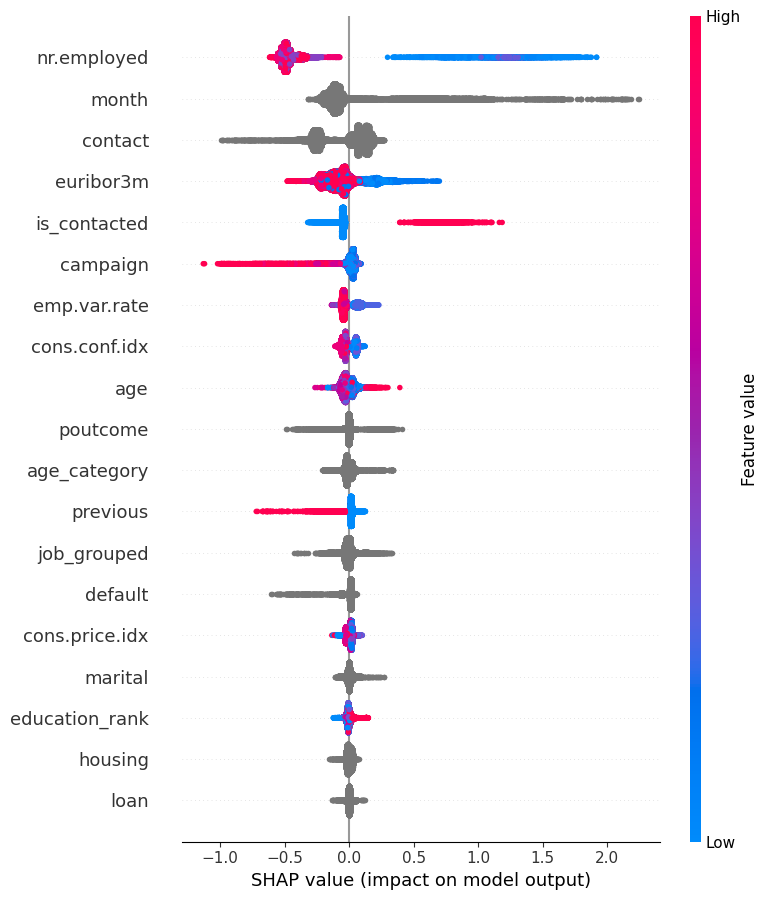

In [ ]:
shap.summary_plot(shap_values, X_train_boost)

***Observations:***
- We can see that the most important feature is nr.employed. When its value is low (blue points), the model more often predicts the positive class, and when it is high (pink points) — the opposite. Similar behavior is observed for euribor3m and emp.var.rate. All three reflect the economic situation in the country and move in the same direction.

- is_contacted shows that if a client has already been contacted before, this is a strong positive signal for the model.

- campaign works the other way around. The more times a client was contacted during the current campaign, the lower the probability of a positive outcome.

- Features such as month, contact and other categorical variables are displayed as grey points. For these features, colour carries no information.

- Features marital, housing, loan and education_rank have almost no impact on predictions — their points are concentrated near zero.

Overall, the model relies primarily on economic indicators and the history of client contacts.

Let’s create a dependency graph for the month.

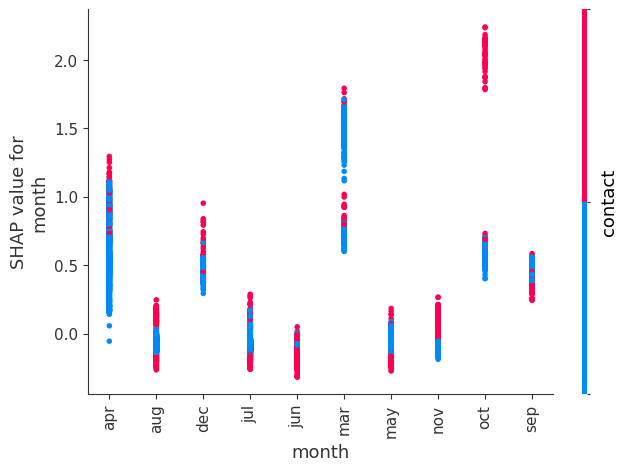

In [ ]:
shap.dependence_plot('month', shap_values, X_train_boost)

***Observations:***

The graph shows that different months have a different impact on the model's predictions.
The strongest positive impact is observed in October and March. This means that clients contacted during these months are much more likely to agree to a deposit.
A negative impact is observed in August, June and July — their values drop below zero, meaning these months reduce the probability of a positive outcome.

The colour of the points represents the contact feature. Pink points (a certain type of contact) are positioned higher than blue points in most months, suggesting that the type of contact additionally strengthens or weakens the effect of the month.

##9.Error Analysis and Model Improvement Recommendations

In [ ]:
err_df = pd.DataFrame({'true': val_targets_boost})
ypred_full = model.predict(X_val_boost)

err_df['pred'] = ypred_full
err_df.head()

,true,pred
8489,0,0
40832,1,1
35671,0,0
35984,0,0
21954,0,0


In [ ]:
err_df.value_counts()

true  pred
0     0       6601
      1        707
1     1        568
      0        360
Name: count, dtype: int64

In [ ]:
errors = err_df[err_df['true'] != err_df['pred']]
errors

,true,pred
2443,1,0
16346,1,0
33874,1,0
33469,1,0
41092,0,1
...,...,...
28687,1,0
29022,1,0
30984,1,0
28898,0,1


In [ ]:
errors_full = X_val_boost.copy()
errors_full['true'] = val_targets_boost.values
errors_full['pred'] = ypred_full
errors_full = errors_full[errors_full['true'] != errors_full['pred']]

In [ ]:
errors_full.head()

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,education_rank,is_contacted,marital,default,housing,loan,contact,month,poutcome,job_grouped,age_category,true,pred
2443,31.0000,4.0000,0.0000,1.1000,93.9940,-36.4000,4.8560,5191.0000,1.0000,0.0000,married,unknown,no,no,telephone,may,nonexistent,blue-collar,30-40,1,0
16346,31.0000,13.0000,0.0000,1.4000,93.9180,-42.7000,4.9610,5228.1000,2.0000,0.0000,married,unknown,no,no,cellular,jul,nonexistent,blue-collar,30-40,1,0
33874,31.0000,1.0000,0.0000,-1.8000,92.8930,-46.2000,1.2810,5099.1000,2.0000,0.0000,married,no,yes,no,cellular,may,nonexistent,office worker,30-40,1,0
33469,32.0000,2.0000,0.0000,-1.8000,92.8930,-46.2000,1.2910,5099.1000,1.0000,0.0000,married,unknown,no,no,cellular,may,nonexistent,blue-collar,30-40,1,0
41092,46.0000,2.0000,2.0000,-1.1000,94.7670,-50.8000,1.0480,4963.6000,2.0000,0.0000,single,no,yes,no,cellular,nov,failure,office worker,40-50,0,1


In [ ]:
fp = errors_full[errors_full['pred'] == 1]
fn = errors_full[errors_full['pred'] == 0]

In [ ]:
top5_features = ['nr.employed', 'month', 'contact', 'euribor3m', 'is_contacted']
numeric_features = X_val_boost[top5_features].select_dtypes(include='number').columns.tolist()

print(pd.DataFrame({
    'FP_mean': fp[numeric_features].mean(),
    'FN_mean': fn[numeric_features].mean()
}).round(2))

               FP_mean   FN_mean
nr.employed  5054.4400 5175.1000
euribor3m       1.0900    3.6600
is_contacted    0.1500    0.0100


***Observations:***

- False Positive (FP)

    With a significant decrease in euribor3m and a slight decrease in nr.employed, the model interprets this as a signal to assign the positive class, although in reality it is negative.
    A slight increase in the is_contacted indicator falsely signaled to the model that the client should be assigned to the positive class.

- False Negative (FN):

    Here the situation for these features is the opposite. An increase in the indicators nr.employed and euribor3m and a decrease in the is_contacted indicator falsely signaled to the model that the client should be assigned to the negative class.

The model makes mistakes due to excessive dependence on economic indicators.
Therefore, it is worth adding features that describe the individual behavior of the client independently of the economic context.

In [ ]:
category_features = X_val_boost[top5_features].select_dtypes(include='category').columns.tolist()
print(pd.DataFrame({
        'FP': fp[category_features].value_counts(normalize=True).round(2),
        'FN': fn[category_features].value_counts(normalize=True).round(2)
    }))

                    FP     FN
month contact                
apr   cellular  0.1900 0.0500
      telephone 0.0200 0.0000
aug   cellular  0.1400 0.1300
      telephone 0.0100 0.0100
dec   cellular  0.0200    NaN
      telephone 0.0000    NaN
jul   cellular  0.0500 0.1900
      telephone 0.0200 0.0200
jun   cellular  0.1300    NaN
      telephone 0.0100 0.0900
mar   cellular  0.0600    NaN
      telephone 0.0100    NaN
may   cellular  0.0800 0.2500
      telephone 0.0100 0.1600
nov   cellular  0.0600 0.0700
      telephone 0.0100 0.0100
oct   cellular  0.0800    NaN
      telephone 0.0200    NaN
sep   cellular  0.0700 0.0000
      telephone 0.0000 0.0100


***Observations:***

- False Positive (FP):

    The highest proportion of false positives occurs in April and August via cellular contact. June also accounts for a significant proportion. This means that the model most often incorrectly predicts the positive class during these months.

- False Negative (FN):

    The highest proportion of missed customers occurs in May and July. That is, the model most often fails to identify actual positive customers during these months.

NaN values indicate that there were no errors of this type in a given month.

The cellular contact type dominates in both types of errors, while telephone has the smallest contribution.

To address this issue, the following options could be considered:
- add a seasonal feature (by grouping months into seasons);
- add features capturing the relationship between the month and economic indicators (euribor3m, nr.employed).

This may help the model better identify seasonal and economic patterns.

- collect more data for the problematic months (April, May, June, July), as the model may not have enough examples to learn from these periods effectively.

